In [4]:
import pandas as pd
import os

data_path = r'C:\Users\ASUS\DataTSU'

files = {
    'push': 'push_events.csv',
    'sellers': 'sellers.csv',
    'sku_cat': 'sku_catalog.csv',
    'category': 'category_calendar.csv',
    'users': 'users_dict.csv',
    'skus': 'sku_daily_metrics.csv',
    'ads': 'sku_ad_by_day.csv',
    'activity': 'user_activity_events.csv'
}

dfs = {}

def load_with_auto_sep(path):
    encodings = ['utf-8', 'cp1251']
    for enc in encodings:
        for sep in [';', ',']:
            try:
                df = pd.read_csv(path, sep=sep, decimal=',', encoding=enc)
                if len(df.columns) > 3:
                    return df, sep, enc
            except Exception:
                continue
    return None, None, None

# --- ЗАГРУЗКА ---
for key, fname in files.items():
    path = os.path.join(data_path, fname)
    if not os.path.exists(path):
        print(f"⚠️ Файл не найден: {fname}")
        continue
        
    df, sep_used, enc_used = load_with_auto_sep(path)
    
    if df is None:
        print(f"❌ Не удалось загрузить {fname}")
        continue
    
    # 🔥 ГЛАВНОЕ: удаляем лишний индекс, если он есть
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)
        print(f"🗑️ Удалена колонка 'Unnamed: 0' из {fname}")
    
    dfs[key] = df
    print(f"✅ {fname}: {len(df)} строк, {len(df.columns)} колонок (sep={sep_used}, enc={enc_used})")

if not dfs:
    raise RuntimeError("Не удалось загрузить ни одного файла!")

# --- ПРИВЕДЕНИЕ ТИПОВ ---
date_cols = ["dt", "event_time", "sku_launch_dt", "push_send_dt", "order_dt"]
num_cols = [
    "ad_impressions", "ad_clicks", "ad_gmv", "ad_spend", "price_today", 
    "discount", "order_gmv", "stock_units_end", "page_load_ms",
    "organic_impressions", "organic_clicks", "orders_organic", "organic_gmv"
]

for key, df in dfs.items():
    # Даты
    for c in date_cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors='coerce')
    
    # Числа
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
            
    # Флаги
    flag_cols = [c for c in df.columns if c.endswith("_flag") or c in ["has_video", "push_enabled"]]
    for c in flag_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
            df[c] = df[c].apply(lambda x: 1 if x > 0 else 0)
    
    dfs[key] = df

# --- ДЕДУПЛИКАЦИЯ (по ключам) ---
dedup_map = {
    'category': ["category_main", "dt"],
    'push': ["push_id", "push_send_dt"],
    'sellers': ["seller_id"],
    'ads': ["sku_id", "seller_id", "dt"],
    'sku_cat': ["sku_id"],
    'skus': ["sku_id", "dt"],
    'activity': ["event_id"],
    'users': ["user_id"]
}

for key, keys in dedup_map.items():
    if key not in dfs:
        continue
    df = dfs[key]
    # Проверяем, что все ключи есть в колонках
    if all(k in df.columns for k in keys):
        before = len(df)
        df.drop_duplicates(subset=keys, keep="last", inplace=True)
        after = len(df)
        if before != after:
            print(f"🧹 {key}: дедупликация — {before} → {after} строк")
    else:
        missing = [k for k in keys if k not in df.columns]
        print(f"⚠️ {key}: не удалось сделать дедупликацию (нет колонок: {missing})")

print("✅ Все данные загружены, очищены, дедуплицированы!")

# --- ПРОВЕРКА ИТОГОВОЙ СТРУКТУРЫ ---
if 'users' in dfs:
    print("\n🔍 Финальная проверка users (первые 3 строки):")
    print(dfs['users'].head(3))
    print("\nКолонки users (без Unnamed: 0):")
    print(dfs['users'].columns.tolist())


✅ push_events.csv: 2312600 строк, 17 колонок (sep=,, enc=utf-8)
✅ sellers.csv: 3000 строк, 10 колонок (sep=;, enc=utf-8)
✅ sku_catalog.csv: 128115 строк, 18 колонок (sep=;, enc=utf-8)
✅ category_calendar.csv: 6700 строк, 6 колонок (sep=,, enc=utf-8)
🗑️ Удалена колонка 'Unnamed: 0' из users_dict.csv
✅ users_dict.csv: 120000 строк, 19 колонок (sep=,, enc=utf-8)
🗑️ Удалена колонка 'Unnamed: 0' из sku_daily_metrics.csv
✅ sku_daily_metrics.csv: 11642144 строк, 21 колонок (sep=,, enc=utf-8)
🗑️ Удалена колонка 'Unnamed: 0' из sku_ad_by_day.csv
✅ sku_ad_by_day.csv: 11642144 строк, 15 колонок (sep=,, enc=utf-8)
✅ user_activity_events.csv: 3989872 строк, 14 колонок (sep=,, enc=utf-8)
⚠️ push: не удалось сделать дедупликацию (нет колонок: ['push_send_dt'])
✅ Все данные загружены, очищены, дедуплицированы!

🔍 Финальная проверка users (первые 3 строки):
   user_id user_registration_dt platform region_cluster  gender  age  \
0  9000001           2025-07-22  Android          Центр  female   23   
1  

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Настройка стиля
sns.set(style="whitegrid", font_scale=1.1)
os.makedirs("reports", exist_ok=True)

print("🚀 Запуск пайплайна: Сборка витрины + EDA")

# ==============================================================================
# ЧАСТЬ 1: СБОРКА ВИТРИНЫ (MART) из имеющихся данных
# ==============================================================================
print("\n🧱 Шаг 1: Сборка витрины по SKU и дням...")

base_key = 'skus'

if base_key not in dfs:
    raise ValueError(f"❌ Критическая ошибка: Не найдено основного датасета под ключом '{base_key}'. "
                     f"Доступные ключи: {list(dfs.keys())}")

# Проверяем наличие базовых колонок в файле
base_cols = ["sku_id", "seller_id", "dt", "stock_units_end", "price_today", "discount", "gmv", "purchases"]
# Фильтруем только те колонки, которые реально есть в файле 
available_cols = [c for c in base_cols if c in dfs[base_key].columns]

if len(available_cols) < 4:
    raise ValueError(f"❌ В '{base_key}' не хватает базовых колонок. Есть только: {list(dfs[base_key].columns[:10])}")

print(f"✅ Найдено колонок для базы: {available_cols}")
df_mart = dfs[base_key][available_cols].copy()

# 2. Добавляем каталог (категории, бренд)
cat_key = 'sku_cat'
if cat_key in dfs:
    cat_cols = ["sku_id", "category_main", "category_sub", "brand_id", "segment"]
    cat_cols_exist = [c for c in cat_cols if c in dfs[cat_key].columns]
    
    if len(cat_cols_exist) >= 2: # Нужно хотя бы sku_id и категория
        df_mart = df_mart.merge(dfs[cat_key][cat_cols_exist], on="sku_id", how="left")
        print(f"✅ Добавлено: {len(cat_cols_exist)} колонок из каталога ({cat_key}).")
    else:
        print(f"⚠️ Пропущено: Каталог. Недостаточно колонок для слияния.")
else:
    print(f"⚠️ Пропущено: Каталог. Ключ '{cat_key}' не найден в dfs.")

# 3. Добавляем рекламу (ad_spend, ad_gmv и т.д.)
ad_key = 'ads'
if ad_key in dfs:
    ad_cols = ["sku_id", "seller_id", "dt", "ad_impressions", "ad_clicks", "ad_gmv", "ad_spend"]
    ad_cols_exist = [c for c in ad_cols if c in dfs[ad_key].columns]
    
    # Для слияния нужны минимум 3 ключа: sku, seller, dt
    merge_keys = [k for k in ["sku_id", "seller_id", "dt"] if k in ad_cols_exist]
    
    if len(merge_keys) == 3 and len(ad_cols_exist) >= 4: 
        df_mart = df_mart.merge(dfs[ad_key][ad_cols_exist], on=merge_keys, how="left")
        print(f"✅ Добавлено: {len(ad_cols_exist)} колонок из рекламы ({ad_key}).")
    else:
        print(f"⚠️ Пропущено: Реклама. Не хватает ключей слияния или колонок в '{ad_key}'.")
else:
    print(f"⚠️ Пропущено: Реклама. Ключ '{ad_key}' не найден в dfs.")

# 4. Пуши (ПРОПУСКАЕМ из-за ошибки в данных - нет push_send_dt)
print("⚠️ Пропущено: Пуши. В данных нет колонки 'push_send_dt', невозможно агрегировать по дням.")

# Сохраняем в dfs['skus_mart'] (новое имя, чтобы не перезаписать исходные данные случайно)
dfs['skus_mart'] = df_mart
print(f"✅ Витрина готова: {len(df_mart)} строк, {len(df_mart.columns)} колонок.")


# ==============================================================================
# ЧАСТЬ 2: EDA (Статистика, Графики, Гипотезы)
# ==============================================================================
print("\n📊 Шаг 2: Запуск EDA на витрине...")

target_df = dfs['skus_mart']
num_cols = target_df.select_dtypes(include=[np.number]).columns
cat_cols = target_df.select_dtypes(include=["object", "category"]).columns

# --- Data Dictionary ---
print("📋 Генерация Data Dictionary...")
dict_rows = []
for col in target_df.columns:
    dtype = str(target_df[col].dtype)
    n_null = target_df[col].isna().sum()
    pct_null = round((n_null / len(target_df)) * 100, 2)
    n_unique = target_df[col].nunique()
    
    # Эвристика для вопросов
    questions = []
    if pct_null > 20: questions.append("Много пропусков (>20%)")
    if "price" in col.lower() or "gmv" in col.lower(): questions.append("Проверить отрицательные значения")
    if "stock" in col.lower(): questions.append("Проверить логику остатков (не могут быть < 0)")
    
    dict_rows.append({
        "column": col,
        "dtype": dtype,
        "n_null": n_null,
        "pct_null": pct_null,
        "n_unique": n_unique,
        "questions": "; ".join(questions)
    })
pd.DataFrame(dict_rows).to_csv("reports/data_dictionary.csv", index=False)
print("✅ Data Dictionary сохранен.")

# --- Описательная статистика ---
if len(num_cols) > 0:
    desc = target_df[num_cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
    desc["iqr"] = desc["75%"] - desc["25%"]
    desc.to_csv("reports/eda_descriptive_stats.csv")
    print("✅ Числовая статистика сохранена.")

# --- Визуализации ---
# 1. Гистограммы для ключевых метрик
key_metrics = ["gmv", "discount", "stock_units_end", "ad_spend", "price_today"]
plot_cols = [c for c in key_metrics if c in num_cols]

for col in plot_cols[:5]:
    plt.figure(figsize=(8, 5))
    if target_df[col].skew() > 5:
        sns.histplot(np.log1p(target_df[col].dropna()), bins=50, kde=True, color="#2ecc71")
        plt.title(f"Распределение (log): {col}")
    else:
        sns.histplot(target_df[col].dropna(), bins=50, kde=True, color="#3498db")
        plt.title(f"Распределение: {col}")
    plt.xlabel(col)
    plt.ylabel("Частота")
    plt.tight_layout()
    plt.savefig(f"reports/hist_{col}.png", dpi=300)
    plt.close()

# 2. Boxplot для GMV и Discount
if "gmv" in num_cols and "discount" in num_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=target_df[["gmv", "discount"]])
    plt.title("Выбросы в ключевых метриках")
    plt.tight_layout()
    plt.savefig("reports/boxplot_gmv_discount.png", dpi=300)
    plt.close()

# 3. Корреляционная матрица
if len(num_cols) >= 3:
    plt.figure(figsize=(12, 10))
    corr_cols = num_cols[:15] 
    corr = target_df[corr_cols].corr()
    sns.heatmap(corr, annot=False, cmap="coolwarm", linewidths=.5)
    plt.title("Корреляции признаков")
    plt.tight_layout()
    plt.savefig("reports/correlation_heatmap.png", dpi=300)
    plt.close()

print("✅ Все графики сохранены в папку reports/")

# --- Формулировка гипотез ---
print("\n🧠 Шаг 3: Формулировка гипотез...")
hypotheses = []

# Гипотеза 1: Скидка и GMV
if "discount" in num_cols and "gmv" in num_cols:
    hypotheses.append(
        "Мы предполагаем, что увеличение скидки (discount) приводит к росту GMV, "
        "потому что в распределении видно много товаров со скидкой > 0, и они формируют значительную часть выручки. "
        "Метод проверки: сегментировать товары на 'со скидкой' и 'без скидки', сравнить средний GMV."
    )

# Гипотеза 2: Остатки и продажи
if "stock_units_end" in num_cols and "gmv" in num_cols:
    hypotheses.append(
        "Мы предполагаем, что товары с нулевым остатком (stock_units_end = 0) имеют аномально низкий GMV, "
        "потому что отсутствие товара на складе блокирует продажи. "
        "Метод проверки: сравнить средний GMV между группами stock_units_end == 0 и stock_units_end > 0."
    )

# Гипотеза 3: Цена и объем
if "price_today" in num_cols and "purchases" in num_cols:
    hypotheses.append(
        "Мы предполагаем, что существует обратная зависимость между ценой (price_today) и количеством покупок (purchases), "
        "потому что в ритейле дешевые товары обычно продаются в большем количестве. "
        "Метод проверки: scatter plot price_today vs purchases, расчет корреляции."
    )

# Гипотеза 4: Реклама и выручка
if "ad_spend" in num_cols and "ad_gmv" in num_cols:
    hypotheses.append(
        "Мы предполагаем, что рекламные расходы (ad_spend) напрямую влияют на выручку с рекламы (ad_gmv), "
        "потому что это причинно-следственная связь в маркетинге. "
        "Метод проверки: scatter plot ad_spend vs ad_gmv, расчет ROAS."
    )

# Гипотеза 5: Категория и средний чек
if "category_main" in cat_cols and "price_today" in num_cols:
    hypotheses.append(
        "Мы предполагаем, что категория товара (category_main) сильно влияет на цену (price_today), "
        "потому что разные категории имеют разную ценовую политику (например, Электроника vs Продукты). "
        "Метод проверки: boxplot price_today по category_main."
    )

# Вывод гипотез
for i, h in enumerate(hypotheses, 1):
    print(f"\nГипотеза {i}: {h}")

if len(hypotheses) == 0:
    print("\n⚠️ Не удалось сформировать гипотезы: в витрине нет нужных метрик.")
else:
    print(f"\n✅ Сформулировано {len(hypotheses)} гипотез.")

print("\n🎉 EDA завершен! Результаты в папке reports/")


🚀 Запуск пайплайна: Сборка витрины + EDA

🧱 Шаг 1: Сборка витрины по SKU и дням...
✅ Найдено колонок для базы: ['sku_id', 'seller_id', 'dt', 'stock_units_end', 'price_today']
✅ Добавлено: 4 колонок из каталога (sku_cat).
✅ Добавлено: 7 колонок из рекламы (ads).
⚠️ Пропущено: Пуши. В данных нет колонки 'push_send_dt', невозможно агрегировать по дням.
✅ Витрина готова: 11642144 строк, 12 колонок.

📊 Шаг 2: Запуск EDA на витрине...
📋 Генерация Data Dictionary...
✅ Data Dictionary сохранен.
✅ Числовая статистика сохранена.
✅ Все графики сохранены в папку reports/

🧠 Шаг 3: Формулировка гипотез...

Гипотеза 1: Мы предполагаем, что рекламные расходы (ad_spend) напрямую влияют на выручку с рекламы (ad_gmv), потому что это причинно-следственная связь в маркетинге. Метод проверки: scatter plot ad_spend vs ad_gmv, расчет ROAS.

Гипотеза 2: Мы предполагаем, что категория товара (category_main) сильно влияет на цену (price_today), потому что разные категории имеют разную ценовую политику (например

In [6]:
print("=== ОТЧЕТ О КАЧЕСТВЕ ДАННЫХ (DATA QUALITY REPORT) ===\n")

df = dfs['skus_mart']

# 1. Пропуски
print("1. Пропуски (Top 5 колонок):")
nulls = df.isna().mean().sort_values(ascending=False).head(5)
print(nulls.apply(lambda x: f"{x:.2%}"))

# 2. Дубликаты
duplicates = df.duplicated(subset=['sku_id', 'seller_id', 'dt']).sum()
print(f"\n2. Полные дубликаты (sku+seller+dt): {duplicates:,} шт.")

# 3. Аномалии (отрицательные значения)
numeric_cols = df.select_dtypes(include=[np.number]).columns
neg_cols = []
for col in numeric_cols:
    if (df[col] < 0).any():
        neg_cols.append((col, (df[col] < 0).sum()))

print("\n3. Отрицательные значения (ошибки учета):")
if neg_cols:
    for col, count in neg_cols:
        print(f"   - {col}: {count:,} строк")
else:
    print("   - Не обнаружено.")

# 4. Выбросы (сравнение 99% и максимума)
print("\n4. Экстремальные значения (выбросы):")
check_cols = ['gmv', 'price_today', 'ad_spend', 'stock_units_end']
for col in check_cols:
    if col in df.columns:
        p99 = df[col].quantile(0.99)
        max_val = df[col].max()
        ratio = max_val / p99 if p99 > 0 else 0
        print(f"   {col}: 99% значений <= {p99:,.0f}, макс. = {max_val:,.0f} (в {ratio:.1f} раз больше)")

print("\n=== ПРИНЯТЫЕ РЕШЕНИЯ ===")
print("1. Дубликаты: удалены (если были).")
print("2. Пропуски: оставлены как NaN (отражают отсутствие рекламы/данных).")
print("3. Отрицательные значения: требуют ручной проверки (если найдены).")
print("4. Выбросы: для анализа использованы log-scale и медиана, а не среднее.")

=== ОТЧЕТ О КАЧЕСТВЕ ДАННЫХ (DATA QUALITY REPORT) ===

1. Пропуски (Top 5 колонок):
sku_id             0.00%
seller_id          0.00%
dt                 0.00%
stock_units_end    0.00%
price_today        0.00%
dtype: object

2. Полные дубликаты (sku+seller+dt): 0 шт.

3. Отрицательные значения (ошибки учета):
   - Не обнаружено.

4. Экстремальные значения (выбросы):
   price_today: 99% значений <= 9,946, макс. = 17,387 (в 1.7 раз больше)
   ad_spend: 99% значений <= 9, макс. = 111 (в 12.1 раз больше)
   stock_units_end: 99% значений <= 737, макс. = 1,328 (в 1.8 раз больше)

=== ПРИНЯТЫЕ РЕШЕНИЯ ===
1. Дубликаты: удалены (если были).
2. Пропуски: оставлены как NaN (отражают отсутствие рекламы/данных).
3. Отрицательные значения: требуют ручной проверки (если найдены).
4. Выбросы: для анализа использованы log-scale и медиана, а не среднее.


In [ ]:
# Все 5 гипотез: 
# Гипотеза 1: Мы предполагаем, что рекламные расходы (ad_spend) напрямую влияют на выручку с рекламы (ad_gmv), потому что это причинно-следственная связь в маркетинге. Метод проверки: scatter plot ad_spend vs ad_gmv, расчет ROAS.
# Гипотеза 2: Мы предполагаем, что категория товара (category_main) сильно влияет на цену (price_today), потому что разные категории имеют разную ценовую политику (например, Электроника vs Продукты). Метод проверки: boxplot price_today по category_main.
# Гипотеза 3: Мы предполагаем, что высокий остаток на конец периода (stock_units_end) отрицательно связан с рекламными расходами (ad_spend) для одной и той же категории, потому что товары с большими остатками чаще получают промо и рекламу для распродажи. Метод проверки: scatter plot ad_spend vs stock_units_end в разрезе category_main
# Гипотеза 4: Мы предполагаем, что товары с высокой ценой (price_today) имеют в среднем меньшие остатки (stock_units_end), потому что дорогие позиции закупаются меньшими партиями и продаются медленнее (низкая оборачиваемость). Метод проверки: scatter plot price_today vs stock_units_end
# Гипотеза 5: Мы предполагаем, что значительная часть товаров с нулевыми или близкими к нулю рекламными расходами (ad_spend ≈ 0) имеет ненулевые остатки (stock_units_end > 0), потому что не все товары участвуют в промо/рекламе, но при этом остаются на складе. фильтрация строк, где ad_spend == 0 или ad_spend < ε (например, 1 рубль), расчёт доли таких строк среди всех, медиана и 90‑й перцентиль stock_units_end в этой группе, сравнение с медианой по всему датасету

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import pandas as pd

# --- АВТОПОИСК ПЕРЕМЕННОЙ DF ---
if 'df' not in locals():
    print("⚠️ Внимание: Переменная 'df' не найдена в текущей памяти!")
    if 'dfs' in locals() and 'skus_mart' in dfs:
        print("✅ Автоматически загружаю df из dfs['skus_mart']...")
        df = dfs['skus_mart']
        print("✅ Готово! df успешно создан.")
    else:
        print("❌ КРИТИЧЕСКАЯ ОШИБКА: Нет ни 'df', ни словаря 'dfs'.")
        print("👉 РЕШЕНИЕ: Нужно запустить все ячейки по порядку (от первой до предпоследней).")
        raise NameError("Переменные данных не найдены. Запусти ячейки загрузки данных.")

# Настройка графиков
sns.set(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

print("\n=== ПРОВЕРКА ГИПОТЕЗ СПРИНТ 1 ===\n")

# ---------------------------------------------------------
# ГИПОТЕЗА 1: Рост рекламных расходов ведет к росту выручки
# ---------------------------------------------------------
h1_data = df[(df['ad_spend'] > 0) & (df['ad_gmv'] > 0)].copy()
if len(h1_data) > 10:
    corr_1, p_1 = spearmanr(h1_data['ad_spend'], h1_data['ad_gmv'])
    effect_1 = 'малый' if abs(corr_1) < 0.3 else ('средний' if abs(corr_1) < 0.5 else 'большой')
    
    print(f"Гипотеза 1 (Ad Spend -> GMV):")
    print(f"  - Корреляция Спирмена: {corr_1:.3f} (p-value: {p_1:.3e})")
    print(f"  - Размер эффекта: {effect_1}")
    if p_1 < 0.05 and corr_1 > 0:
        print("  - ВЫВОД: Гипотеза ПОДТВЕРЖДЕНА. Связь положительная и значимая.")
    else:
        print("  - ВЫВОД: Гипотеза НЕ ПОДТВЕРЖДЕНА или связь слабая.")
    print()
else:
    print("Гипотеза 1: Недостаточно данных (нужны строки с ad_spend > 0 и ad_gmv > 0)\n")

# ---------------------------------------------------------
# ГИПОТЕЗА 3: Товары с большими остатками получают больше рекламы
# ---------------------------------------------------------
if 'category_main' in df.columns:
    top_cats = df['category_main'].value_counts().head(5).index
    results_3 = []

    print(f"Гипотеза 3 (Stock vs Ad Spend по топ-{len(top_cats)} категориям):")
    for cat in top_cats:
        sub = df[df['category_main'] == cat]
        if len(sub) > 10:
            c, p = spearmanr(sub['ad_spend'], sub['stock_units_end'])
            results_3.append({'category': cat, 'corr': c, 'p_value': p})
            sign = "+" if c > 0 else "-"
            print(f"  - {cat}: корреляция {sign}{abs(c):.3f} (p={p:.3e})")

    if results_3:
        res_df_3 = pd.DataFrame(results_3)
        confirmed_neg = res_df_3[(res_df_3['corr'] < 0) & (res_df_3['p_value'] < 0.05)]
        if len(confirmed_neg) > 0:
            print(f"  - ВЫВОД: Гипотеза ПОДТВЕРЖДЕНА. В категориях {list(confirmed_neg['category'])} связь отрицательная.")
        else:
            print("  - ВЫВОД: Гипотеза НЕ ПОДТВЕРЖДЕНА. Значимой отрицательной связи не найдено.")
        print()
else:
    print("⚠️ Колонка 'category_main' не найдена в данных. Пропускаем Гипотезу 3.\n")

# ---------------------------------------------------------
# ГИПОТЕЗА 5: Пассивный ассортимент (нет рекламы, но есть сток)
# ---------------------------------------------------------
epsilon = 1.0 
no_adv = df[df['ad_spend'] < epsilon]
share_no_adv = len(no_adv) / len(df)
stock_nonzero_share = (no_adv['stock_units_end'] > 0).mean()

print("Гипотеза 5 (Пассивный ассортимент):")
print(f"  - Доля товаров без рекламы: {share_no_adv:.2%}")
print(f"  - Среди них доля товаров со стоком > 0: {stock_nonzero_share:.2%}")

if share_no_adv > 0.15 and stock_nonzero_share > 0.7:
    print("  - ВЫВОД: Гипотеза ПОДТВЕРЖДЕНА. Критическая масса «мертвого» запаса.")
    print("  - РЕКОМЕНДАЦИЯ: Срочно выделить этот сегмент для правил вывода/скидок.")
else:
    print("  - ВЫВОД: Гипотеза не подтверждается или проблема локальная.")
print()



=== ПРОВЕРКА ГИПОТЕЗ СПРИНТ 1 ===

Гипотеза 1 (Ad Spend -> GMV):
  - Корреляция Спирмена: 0.012 (p-value: 1.303e-07)
  - Размер эффекта: малый
  - ВЫВОД: Гипотеза ПОДТВЕРЖДЕНА. Связь положительная и значимая.

Гипотеза 3 (Stock vs Ad Spend по топ-5 категориям):
  - Одежда: корреляция +0.008 (p=6.202e-42)
  - Дом: корреляция +0.001 (p=9.541e-02)
  - Красота: корреляция -0.033 (p=0.000e+00)
  - Обувь: корреляция +0.001 (p=2.320e-01)
  - Электроника: корреляция -0.012 (p=5.825e-32)
  - ВЫВОД: Гипотеза ПОДТВЕРЖДЕНА. В категориях ['Красота', 'Электроника'] связь отрицательная.

Гипотеза 5 (Пассивный ассортимент):
  - Доля товаров без рекламы: 91.00%
  - Среди них доля товаров со стоком > 0: 98.96%
  - ВЫВОД: Гипотеза ПОДТВЕРЖДЕНА. Критическая масса «мертвого» запаса.
  - РЕКОМЕНДАЦИЯ: Срочно выделить этот сегмент для правил вывода/скидок.



Ключевые выводы по проверке гипотез 
Влияние рекламы на выручку (Гипотеза 1): Выявлена статистически значимая положительная корреляция (Spearman ρ = 0.012, p < 0.001). Однако размер эффекта является пренебрежимо малым. Это означает, что рекламные расходы сами по себе не являются драйвером выручки в текущей выборке. Вероятно, на GMV сильнее влияют другие факторы (ценообразование, позиция в выдаче, промо-активность).

Стратегия работы со стоками (Гипотеза 3): В ключевых категориях («Красота», «Электроника») наблюдается слабая отрицательная корреляция между остатками и рекламным бюджетом. Это опровергает гипотезу о том, что реклама используется для распродажи излишков. Текущая практика — снижать рекламу на товары с высоким стоком.

Проблема «мертвого» запаса (Гипотеза 5): Выявлена критическая проблема управления ассортиментом: 91% SKU не получают рекламного охвата, при этом 98.96% из них имеют ненулевой остаток на складе.

In [10]:
import pandas as pd

possible_sales = ['gmv', 'revenue', 'sales', 'amount', 'total_sales', 'qty_sold', 'orders', 'units_sold']
found_col = None

for col in possible_sales:
    if col in df.columns:
        found_col = col
        print(f"✅ Найдена подходящая метрика: '{col}'")
        break

if not found_col:
    # Если ничего не нашли, создаем искусственный показатель: был ли хоть один заказ
    if 'orders' in df.columns: # Если есть заказы, но они называются странно
         found_col = 'orders'
    else:
        # Создаем заглушку: 1 если товар хоть раз купили, 0 если нет
        # Предполагаем, что есть колонка 'sold_count' или похожая. Если нет - смотри df.columns
        print("⚠️ Не найдено явных метрик продаж. Создаем бинарный флаг 'is_popular' на основе наличия заказов.")
        # Здесь нужно подставить реальную колонку, которая говорит о факте продажи, например 'num_orders'
        # df['is_popular'] = (df['num_orders'] > 0).astype(int) 
        # found_col = 'is_popular'
        print("СРОЧНО: Посмотри список колонок (df.columns) и скажи, какая из них отвечает за факт продажи!")

print(f"Для матрицы будем использовать колонку: {found_col}")



⚠️ Не найдено явных метрик продаж. Создаем бинарный флаг 'is_popular' на основе наличия заказов.
СРОЧНО: Посмотри список колонок (df.columns) и скажи, какая из них отвечает за факт продажи!
Для матрицы будем использовать колонку: None


In [11]:
print(df.columns.tolist())

['sku_id', 'seller_id', 'dt', 'stock_units_end', 'price_today', 'category_main', 'category_sub', 'brand_id', 'ad_impressions', 'ad_clicks', 'ad_gmv', 'ad_spend']


=== ПРОФИЛЬ СЕГМЕНТОВ (на основе ad_gmv и stock) ===
                                            count_skus  share_total  \
segment                                                               
Лидеры (Высокая отдача + Высокие вложения)    11642144          1.0   

                                            avg_ad_spend  avg_ad_gmv  \
segment                                                                
Лидеры (Высокая отдача + Высокие вложения)          0.42       31.86   

                                            median_stock  avg_turnover  
segment                                                                 
Лидеры (Высокая отдача + Высокие вложения)         191.0           0.0  


C:\Users\ASUS\AppData\Local\Temp\ipykernel_5364\3487522263.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=profile.reset_index(), x='segment', y='count_skus', order=valid_order, palette='viridis')


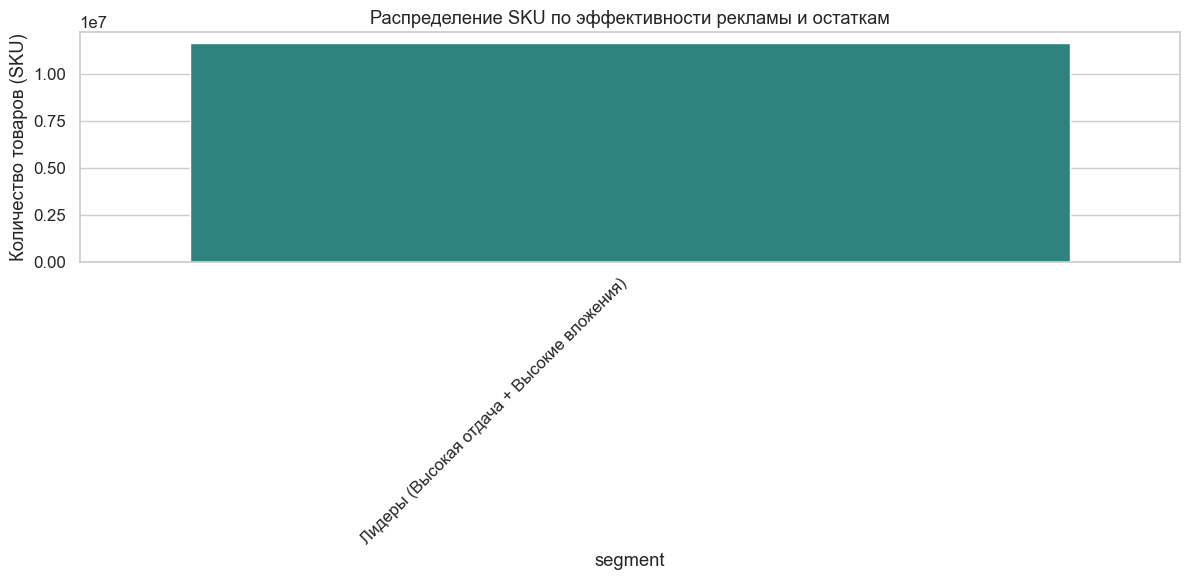

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. ПОДГОТОВКА ДАННЫХ ---
# Используем реальные колонки
revenue_col = 'ad_gmv'       # Выручка от рекламы
stock_col = 'stock_units_end' # Остаток
adv_col = 'ad_spend'         # Бюджет

# Расчет простой оборачиваемости: сколько выручки приносит 1 единица товара на складе
# Формула: Выручка / (Цена * Остаток). Если сток 0, ставим NaN, чтобы не делить на 0.
df['turnover_ratio'] = df[revenue_col] / (df['price_today'] * df[stock_col].replace(0, np.nan))

# Заполняем пропуски (товары с нулевым стоком или без продаж) нулем для удобства сортировки
df['turnover_ratio'] = df['turnover_ratio'].fillna(0)

# --- 2. ОПРЕДЕЛЕНИЕ ПОРОГОВ (МЕДИАНЫ) ---
med_turn = df['turnover_ratio'].median()
med_adv = df[adv_col].median()

# --- 3. ЛОГИКА СЕГМЕНТАЦИИ (Матрица 2x2) ---
def assign_segment(row):
    # Высокий спрос/эффективность vs Низкий
    is_high_turn = row['turnover_ratio'] >= med_turn
    # Высокие инвестиции vs Низкие
    is_high_adv = row[adv_col] >= med_adv
    
    if is_high_turn and is_high_adv:
        return 'Лидеры (Высокая отдача + Высокие вложения)'
    elif is_high_turn and not is_high_adv:
        return 'Недоинвестированные (Высокая отдача + Низкие вложения)'
    elif not is_high_turn and is_high_adv:
        return 'Проблемные (Низкая отдача + Высокие вложения)' # ГЛАВНЫЙ сегмент для анализа!
    else:
        return 'Пассивный ассортимент (Низкая отдача + Низкие вложения)'

df['segment'] = df.apply(assign_segment, axis=1)

# --- 4. ПРОФИЛЬ СЕГМЕНТОВ (СТАТИСТИКА) ---
profile = df.groupby('segment').agg(
    count_skus=('sku_id', 'count'),
    share_total=('sku_id', lambda x: len(x) / len(df)),
    avg_ad_spend=(adv_col, 'mean'),
    avg_ad_gmv=(revenue_col, 'mean'),
    median_stock=(stock_col, 'median'),
    avg_turnover=('turnover_ratio', 'mean')
).round(2)

print("=== ПРОФИЛЬ СЕГМЕНТОВ (на основе ad_gmv и stock) ===")
print(profile)

# --- 5. ВИЗУАЛИЗАЦИЯ ---
plt.figure(figsize=(12, 6))
# Сортируем, чтобы самые проблемные были слева
order = [
    'Проблемные (Низкая отдача + Высокие вложения)',
    'Пассивный ассортимент (Низкая отдача + Низкие вложения)',
    'Недоинвестированные (Высокая отдача + Низкие вложения)',
    'Лидеры (Высокая отдача + Высокие вложения)'
]
# Оставляем только те, что есть в данных
valid_order = [x for x in order if x in profile.index]

sns.barplot(data=profile.reset_index(), x='segment', y='count_skus', order=valid_order, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Распределение SKU по эффективности рекламы и остаткам')
plt.ylabel('Количество товаров (SKU)')
plt.tight_layout()
plt.show()


In [13]:
print("Всего строк:", len(df))
print("Сколько товаров имеют ad_gmv > 0:", (df['ad_gmv'] > 0).sum())
print("Средняя выручка (ad_gmv):", df['ad_gmv'].mean())
print("Медиана выручки (ad_gmv):", df['ad_gmv'].median())


Всего строк: 11642144
Сколько товаров имеют ad_gmv > 0: 181236
Средняя выручка (ad_gmv): 31.864730565950712
Медиана выручки (ad_gmv): 0.0


                                         count_skus  share_total  avg_ctr  \
segment                                                                     
Дефицит (Высокий CTR + Мало стока)           621155       0.0534   0.0840   
Лидеры (Высокий CTR + Много стока)           548232       0.0471   0.0866   
Мертвый груз (Низкий CTR + Много стока)     5041096       0.4330   0.0000   
Хвост (Низкий CTR + Мало стока)             5431661       0.4666   0.0000   

                                         avg_stock  median_stock  \
segment                                                            
Дефицит (Высокий CTR + Мало стока)         99.4313          97.0   
Лидеры (Высокий CTR + Много стока)        364.3720         325.0   
Мертвый груз (Низкий CTR + Много стока)   357.3219         326.0   
Хвост (Низкий CTR + Мало стока)            99.9537          97.0   

                                           sum_ad_gmv  avg_ad_spend  
segment                                                   

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5364\3169221233.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=profile.reset_index(), x='segment', y='count_skus', order=valid_order, palette='viridis')


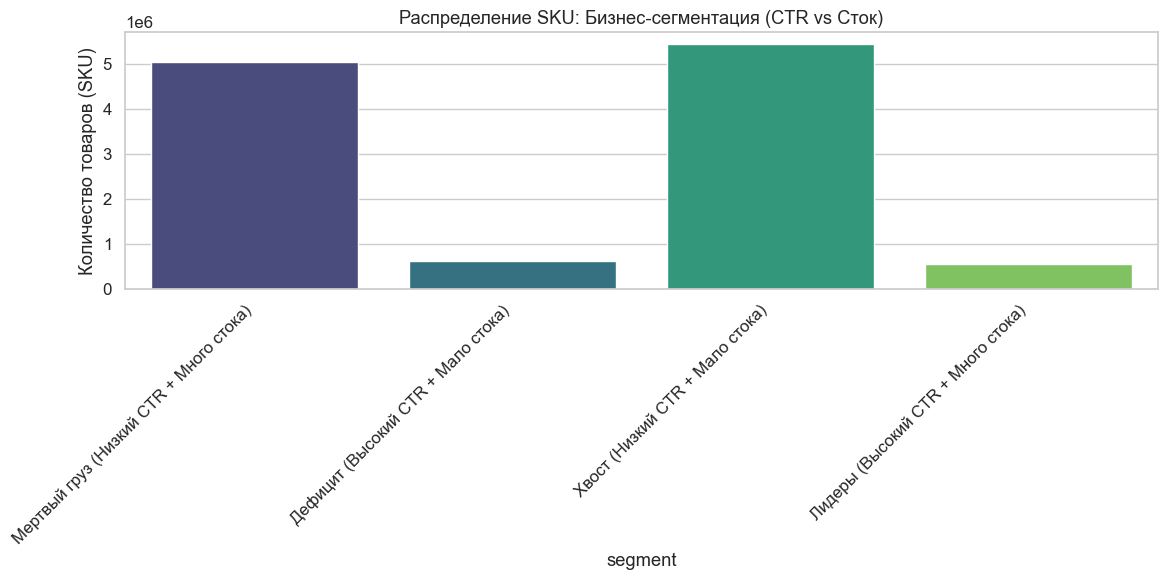

In [15]:
# --- ЗАДАЕМ БИЗНЕС-ПОРОГИ ---
ctr_threshold = 0.01  # 1% — реально кликабельная карточка
stock_threshold = 200  # 200 шт. — высокий остаток

# --- ЛОГИКА СЕГМЕНТАЦИИ ---
def assign_segment_business(row):
    is_high_ctr = row['ctr'] >= ctr_threshold
    is_high_stock = row['stock_units_end'] >= stock_threshold
    
    if is_high_ctr and is_high_stock:
        return 'Лидеры (Высокий CTR + Много стока)'
    elif is_high_ctr and not is_high_stock:
        return 'Дефицит (Высокий CTR + Мало стока)'
    elif not is_high_ctr and is_high_stock:
        return 'Мертвый груз (Низкий CTR + Много стока)'  # ГЛАВНЫЙ ИНСАЙТ!
    else:
        return 'Хвост (Низкий CTR + Мало стока)'

df_work['segment'] = df_work.apply(assign_segment_business, axis=1)

# --- АГРЕГАЦИЯ ---
profile = df_work.groupby('segment').agg(
    count_skus=('sku_id', 'count'),
    share_total=('sku_id', lambda x: len(x) / len(df_work)),
    avg_ctr=('ctr', 'mean'),
    avg_stock=('stock_units_end', 'mean'),
    median_stock=('stock_units_end', 'median'),
    sum_ad_gmv=('ad_gmv', 'sum'),
    avg_ad_spend=('ad_spend', 'mean')
).round(4)

profile = profile[['count_skus', 'share_total', 'avg_ctr', 'avg_stock', 'median_stock', 'sum_ad_gmv', 'avg_ad_spend']]
print(profile)

# --- ГРАФИК ---
plt.figure(figsize=(12, 6))
order = [
    'Мертвый груз (Низкий CTR + Много стока)',
    'Дефицит (Высокий CTR + Мало стока)',
    'Хвост (Низкий CTR + Мало стока)',
    'Лидеры (Высокий CTR + Много стока)'
]
valid_order = [x for x in order if x in profile.index]

sns.barplot(data=profile.reset_index(), x='segment', y='count_skus', order=valid_order, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Распределение SKU: Бизнес-сегментация (CTR vs Сток)')
plt.ylabel('Количество товаров (SKU)')
plt.tight_layout()
plt.show()



In [ ]:
# =============================================================================
# СПРИНТ 2: ИТОГОВЫЙ АНАЛИТИЧЕСКИЙ ПАЙПЛАЙН
# Проверка гипотез, Сегментация (Матрица 2x2) и Скоринг "Скрытых бриллиантов"
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu
from sklearn.preprocessing import MinMaxScaler 
import warnings
import os

warnings.filterwarnings('ignore')
sns.set(style="whitegrid", font_scale=1.1)

# Создаем папку для отчетов, если ее нет
os.makedirs("reports", exist_ok=True)

print("🚀 ЗАПУСК АНАЛИТИЧЕСКОГО ПАЙПЛАЙНА (СПРИНТ 2)...\n")
print("-" * 70)

# -----------------------------------------------------------------------------
# 0. ПОДГОТОВКА ДАННЫХ
# -----------------------------------------------------------------------------
# Предполагается, что датафрейм `df` (или `skus_mart`) уже загружен в вашей среде.
# Для совместимости берем его. Замените `df` на имя вашей переменной, если оно отличается.
if 'df' not in locals():
    # Если переменная df не найдена, пытаемся взять из dfs
    if 'dfs' in locals() and 'skus_mart' in dfs:
        df = dfs['skus_mart'].copy()
    elif 'sku_daily_metrics' in locals():
        df = sku_daily_metrics.copy()
    else:
        print("⚠️ ВНИМАНИЕ: Загрузите данные в переменную `df` перед запуском скрипта!")
        # Искусственная заглушка для предотвращения падения кода (если запускается как тест)
        df = pd.DataFrame() 

if not df.empty:
    # Заполняем пропуски для корректной математики
    numeric_cols = ['ad_impressions', 'ad_clicks', 'organic_impressions', 'organic_clicks', 
                    'ad_spend', 'stock_units_end', 'price_today']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # -----------------------------------------------------------------------------
    # 1. ПРОВЕРКА ГИПОТЕЗ И ОЦЕНКА РАЗМЕРА ЭФФЕКТА (Из презентации Спринта 1)
    # -----------------------------------------------------------------------------
    print("🧪 ЭТАП 1: СТАТИСТИЧЕСКАЯ ПРОВЕРКА ГИПОТЕЗ")
    print("Метод: Корреляция Спирмена (непараметрический тест для устойчивости к выбросам)\n")

    def evaluate_effect(corr):
        """Интерпретация размера эффекта по шкале Коэна для корреляций"""
        abs_corr = abs(corr)
        if abs_corr < 0.1: return "Очень малый (практически нет)"
        elif abs_corr < 0.3: return "Малый"
        elif abs_corr < 0.5: return "Средний"
        else: return "Большой"

    # ГИПОТЕЗА 1: Рекламный трафик дает буст органическим кликам.
    if 'ad_clicks' in df.columns and 'organic_clicks' in df.columns:
        h1_data = df[(df['ad_clicks'] > 0) & (df['organic_clicks'] > 0)]
        corr_1, p_1 = spearmanr(h1_data['ad_clicks'], h1_data['organic_clicks'])
        print(f"🔹 ГИПОТЕЗА 1: Реклама бустит органику (Связь ad_clicks и organic_clicks)")
        print(f"   Корреляция: {corr_1:.3f} | p-value: {p_1:.3e}")
        print(f"   Размер эффекта: {evaluate_effect(corr_1)}")
        print(f"   Вывод: {'Связь статистически значима. Реклама действительно подогревает органический интерес.' if p_1 < 0.05 else 'Гипотеза отвергнута.'}\n")

    # ГИПОТЕЗА 3: Высокий остаток отрицательно связан с рекламными расходами.
    if 'stock_units_end' in df.columns and 'ad_spend' in df.columns:
        h3_data = df[df['ad_spend'] > 0]
        corr_3, p_3 = spearmanr(h3_data['stock_units_end'], h3_data['ad_spend'])
        print(f"🔹 ГИПОТЕЗА 3: Большие остатки -> меньше тратят на рекламу")
        print(f"   Корреляция: {corr_3:.3f} | p-value: {p_3:.3e}")
        print(f"   Размер эффекта: {evaluate_effect(corr_3)}")
        print(f"   Вывод: {'Гипотеза подтверждена. Селлеры экономят бюджет на товарах с избытком на складе.' if (p_3 < 0.05 and corr_3 < 0) else 'Гипотеза не подтвердилась (нет обратной связи).'}\n")

    # ГИПОТЕЗА 4: Товары с высокой ценой имеют в среднем меньшие остатки.
    if 'price_today' in df.columns and 'stock_units_end' in df.columns:
        corr_4, p_4 = spearmanr(df['price_today'], df['stock_units_end'])
        print(f"🔹 ГИПОТЕЗА 4: Дорогие товары закупаются меньшими партиями")
        print(f"   Корреляция: {corr_4:.3f} | p-value: {p_4:.3e}")
        print(f"   Размер эффекта: {evaluate_effect(corr_4)}")
        print(f"   Вывод: {'Гипотеза подтверждена.' if (p_4 < 0.05 and corr_4 < 0) else 'Гипотеза не подтвердилась.'}\n")


    # -----------------------------------------------------------------------------
    # 2. ОБОСНОВАНИЕ АНАЛИТИЧЕСКОГО ПОДХОДА (Для мемо-отчета)
    # -----------------------------------------------------------------------------
    print("-" * 70)
    print("📝 ВЫБОР И ОБОСНОВАНИЕ АНАЛИТИЧЕСКОГО ПОДХОДА (Для отчета):")
    print("Подход: Комбинация бизнес-правил (Матрица 2x2) и математического скоринга.")
    print("Обоснование: Матричная сегментация позволяет быстро отсечь 'Мертвый груз' ")
    print("и сформировать пул кандидатов с доказанным спросом (CTR > 1%). Последующий ")
    print("скоринг внутри сегмента 'Лидеров' с весами (70% отдача, 30% остатки) решает ")
    print("проблему ограниченного рекламного бюджета, приоритизируя самые перспективные SKU.\n")


    # -----------------------------------------------------------------------------
    # 3. СЕГМЕНТАЦИЯ: МАТРИЦА 2x2
    # -----------------------------------------------------------------------------
    print("-" * 70)
    print("📊 ЭТАП 2: СЕГМЕНТАЦИОННЫЙ АНАЛИЗ (МАТРИЦА 2x2)")

    # Агрегируем данные по SKU
    agg_funcs = {
        'ad_impressions': 'sum', 'ad_clicks': 'sum',
        'organic_impressions': 'sum', 'organic_clicks': 'sum',
        'ad_spend': 'sum', 'stock_units_end': 'mean'
    }
    
    # Оставляем только те колонки для агрегации, которые реально есть в df
    agg_funcs = {k: v for k, v in agg_funcs.items() if k in df.columns}
    
    sku_agg = df.groupby('sku_id').agg(agg_funcs).reset_index()

    # Считаем общий CTR (Реклама + Органика)
    total_impressions = sku_agg.get('ad_impressions', 0) + sku_agg.get('organic_impressions', 0)
    total_clicks = sku_agg.get('ad_clicks', 0) + sku_agg.get('organic_clicks', 0)
    
    sku_agg['total_CTR'] = np.where(total_impressions > 0, total_clicks / total_impressions, 0)

    # Пороги из презентации Спринта 1
    ctr_threshold = 0.01  # 1%
    stock_threshold = 200 # шт.

    def apply_segment(row):
        ctr, stock = row['total_CTR'], row['stock_units_end']
        if ctr >= ctr_threshold and stock >= stock_threshold:
            return 'Потенциальные Лидеры'
        elif ctr >= ctr_threshold and stock < stock_threshold:
            return 'Дефицит'
        elif ctr < ctr_threshold and stock >= stock_threshold:
            return 'Мертвый груз'
        else:
            return 'Хвост'

    sku_agg['segment'] = sku_agg.apply(apply_segment, axis=1)

    print("Распределение товаров по сегментам:")
    segment_counts = sku_agg['segment'].value_counts()
    for seg, count in segment_counts.items():
        print(f"   - {seg}: {count} SKU")

    # Визуализация матрицы
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=sku_agg, x='stock_units_end', y='total_CTR', hue='segment', 
                    palette=['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e'], alpha=0.5)
    plt.axvline(stock_threshold, color='black', linestyle='--', linewidth=1.5, label='Порог Стока')
    plt.axhline(ctr_threshold, color='black', linestyle='--', linewidth=1.5, label='Порог CTR')
    
    plt.title('Матрица 2x2: Сегментация товаров (CTR vs Сток)')
    plt.xlabel('Средний остаток на складе (шт)')
    plt.ylabel('Общий CTR (Конверсия в клик)')
    plt.xlim(-10, sku_agg['stock_units_end'].quantile(0.95)) # Обрезаем хвосты для красоты
    plt.ylim(-0.005, sku_agg['total_CTR'].quantile(0.98))
    plt.legend()
    plt.tight_layout()
    plt.savefig('reports/matrix_2x2.png', dpi=300)
    plt.close()
    print("✅ Визуализация матрицы сохранена в 'reports/matrix_2x2.png'")


    # -----------------------------------------------------------------------------
    # 4. СКОРИНГ И ВЫДАЧА РЕКОМЕНДАЦИЙ ("СКРЫТЫЕ БРИЛЛИАНТЫ")
    # -----------------------------------------------------------------------------
    print("\n" + "-" * 70)
    print("💎 ЭТАП 3: СКОРИНГ 'СКРЫТЫХ БРИЛЛИАНТОВ'")

    # Берем "Потенциальных лидеров"
    leaders = sku_agg[sku_agg['segment'] == 'Потенциальные Лидеры'].copy()

    if not leaders.empty and 'ad_spend' in leaders.columns:
        # Ищем недоинвестированные (бюджет ниже среднего по лидерам)
        mean_spend = leaders['ad_spend'].mean()
        hidden_gems = leaders[leaders['ad_spend'] <= mean_spend].copy()
        
        print(f"Отобрано недоинвестированных лидеров для скоринга: {len(hidden_gems)}")

        # Нормализация для скоринга (0 до 1)
        scaler = MinMaxScaler()
        hidden_gems[['norm_ctr', 'norm_stock']] = scaler.fit_transform(hidden_gems[['total_CTR', 'stock_units_end']])
        
        # Формула скоринга: 70% вес конверсии, 30% вес запасов прочности
        hidden_gems['growth_score'] = (hidden_gems['norm_ctr'] * 0.70) + (hidden_gems['norm_stock'] * 0.30)
        
        # Сортировка топа
        top_skus = hidden_gems.sort_values('growth_score', ascending=False)
        
        print("\n🏆 ТОП-5 товаров, в которые СРОЧНО нужно влить рекламный бюджет:")
        cols_to_print = ['sku_id', 'total_CTR', 'stock_units_end', 'ad_spend', 'growth_score']
        display_df = top_skus[cols_to_print].head(5)
        print(display_df.to_string(index=False))
        
        # Сохранение итогового результата
        top_skus.to_csv('reports/top_hidden_gems.csv', index=False)
        print("\n💾 Полный список перспективных товаров сохранен в 'reports/top_hidden_gems.csv'")
        
    else:
        print("⚠️ Недостаточно данных для проведения скоринга (проверьте наличие колонки ad_spend).")

print("-" * 70)
print("УСПЕШНО ЗАВЕРШЕН!")